# Scenario

- Problem Statement
- You are a manager in a local service centre with

- 4 drivers in your team
- 15 parcel capacity per vehicle
- 16 destinations to cover in the neighbourhood named Dj with j in [1, 16]
- D0 is the centre
- 1 route per driver

# Distance Matrix
To build your model, you need to provide a distance matrix M as input, defined by

- M(i, j) with i, j in [0, 16]
- M(i, j) = distance between Di and Dj
- This distance matrix will be loaded from an Excel file.

# Demand: number of parcels to deliver to each location
- We will use a Python list here with the first value at zero (because you don’t deliver anything in the centre)

- Demand = [0, 1, 1, 2, 4, 2, 4, 8, 8, 1, 2, 1, 2, 4, 4, 8, 8]
# Objective
- Deliver all parcels with a minimum number of drivers
- Optimise the routing to minimise the distance covered per route

# Import libraries

In [2]:
import pandas as pd
import numpy as np 
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt

# Load distance matrix

In [3]:
distance_matrix = pd.read_csv('distance_matrix.csv', index_col=0)
distance_matrix

,col0,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16
row0,0,548,776,696,582,274,502,194,308,194,536,502,388,354,468,776,662
row1,548,0,684,308,194,502,730,354,696,742,1084,594,480,674,1016,868,1210
row2,776,684,0,992,878,502,274,810,468,742,400,1278,1164,1130,788,1552,754
row3,696,308,992,0,114,650,878,502,844,890,1232,514,628,822,1164,560,1358
row4,582,194,878,114,0,536,764,388,730,776,1118,400,514,708,1050,674,1244
row5,274,502,502,650,536,0,228,308,194,240,582,776,662,628,514,1050,708
row6,502,730,274,878,764,228,0,536,194,468,354,1004,890,856,514,1278,480
row7,194,354,810,502,388,308,536,0,342,388,730,468,354,320,662,742,856
row8,308,696,468,844,730,194,194,342,0,274,388,810,696,662,320,1084,514
row9,194,742,742,890,776,240,468,388,274,0,342,536,422,388,274,810,468


In [4]:
data = {}
data['distance_matrix'] = distance_matrix
data["demands"] = [0, 1, 1, 2, 4, 2, 4, 8, 8, 1, 2, 1, 2, 4, 4, 8, 8]
data["vehicle_capacities"] = [15, 15, 15, 15]
data["num_vehicles"] = 4
data["depot"] = 0

# Build your model with constraints and create functions to calculate distances and order quantities

In [5]:
# Create the routing index manager.
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']), data['num_vehicles'],data['depot'])
# Create Routing Model
routing = pywrapcp.RoutingModel(manager)

# Calculate Distance between two nodes
distance_matrix_np = distance_matrix.values
def distance_callback(from_index, to_index):
    """Returns the distance between the two nodes."""
    # Convert from routing variable Index to distance matrix NodeIndex.
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return int(distance_matrix_np[from_node][to_node])

# Get the order quantity of each node (location)
def demand_callback(from_index):
      """Returns the demand of the node."""
      from_node = manager.IndexToNode(from_index)
      return data['demands'][from_node]

# Create and register a transit callback.
transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Define cost of each arc.
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# # Add Capacity constraint.
demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,  # null capacity slack
    data["vehicle_capacities"],  # vehicle maximum capacities
    True,  # start cumul to zero
    "Capacity",
)



True

In [6]:
  # Setting first solution heuristic.
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
search_parameters.time_limit.FromSeconds(1)

In [7]:
# Solve the problem.
solution = routing.SolveWithParameters(search_parameters)

In [8]:
# print solution
if solution:
    total_distance = 0
    total_load = 0
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        plan_output = 'Route for driver {}:\n'.format(vehicle_id)
        route_distance = 0
        route_load = 0
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_load += data['demands'][node_index]
            plan_output += ' {0} Parcels({1}) -> '.format(node_index, route_load)
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id)
        plan_output += ' {0} Parcels({1})\n'.format(manager.IndexToNode(index),
                                                 route_load)
        plan_output += 'Distance of the route: {} (m)\n'.format(route_distance)
        plan_output += 'Parcels Delivered: {} (parcels)\n'.format(route_load)
        print(plan_output)
        total_distance += route_distance
        total_load += route_load
    print('Total distance of all routes: {:,} (m)'.format(total_distance))
    print('Parcels Delivered: {:,}/{:,}'.format(total_load, sum(data['demands'])))
else:
    print('No Solution')

Route for driver 0:
 0 Parcels(0) ->  7 Parcels(8) ->  3 Parcels(10) ->  4 Parcels(14) ->  1 Parcels(15) ->  0 Parcels(15)
Distance of the route: 1552 (m)
Parcels Delivered: 15 (parcels)

Route for driver 1:
 0 Parcels(0) ->  14 Parcels(4) ->  16 Parcels(12) ->  10 Parcels(14) ->  9 Parcels(15) ->  0 Parcels(15)
Distance of the route: 1552 (m)
Parcels Delivered: 15 (parcels)

Route for driver 2:
 0 Parcels(0) ->  12 Parcels(2) ->  11 Parcels(3) ->  15 Parcels(11) ->  13 Parcels(15) ->  0 Parcels(15)
Distance of the route: 1552 (m)
Parcels Delivered: 15 (parcels)

Route for driver 3:
 0 Parcels(0) ->  8 Parcels(8) ->  2 Parcels(9) ->  6 Parcels(13) ->  5 Parcels(15) ->  0 Parcels(15)
Distance of the route: 1552 (m)
Parcels Delivered: 15 (parcels)

Total distance of all routes: 6,208 (m)
Parcels Delivered: 60/60


In [9]:
def extract_routes(data, manager, routing, solution):
    routes = []
    total_distance = 0
    total_load = 0

    if solution is None:
        print("No solution found.")
        return pd.DataFrame()

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_nodes = []
        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_nodes.append(node_index)
            route_load += data["demands"][node_index]

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )

        route_nodes.append(manager.IndexToNode(index))

        total_distance += route_distance
        total_load += route_load

        routes.append({
            "Driver": f"Driver {vehicle_id + 1}",
            "Route Nodes": route_nodes,
            "Route": " → ".join(["Depot" if node == 0 else f"D{node}" for node in route_nodes]),
            "Parcels Delivered": route_load,
            "Distance (m)": route_distance,
            "Capacity": data["vehicle_capacities"][vehicle_id],
            "Capacity Utilization": route_load / data["vehicle_capacities"][vehicle_id]
        })

    route_df = pd.DataFrame(routes)

    print("Route Optimization Result")
    print(route_df[["Driver", "Route", "Parcels Delivered", "Distance (m)", "Capacity Utilization"]])
    print()
    print(f"Total parcels delivered: {total_load}")
    print(f"Total optimized distance: {total_distance} m")

    return route_df

route_df = extract_routes(data, manager, routing, solution)
route_df

Route Optimization Result
     Driver                                  Route  Parcels Delivered  \
0  Driver 1      Depot → D7 → D3 → D4 → D1 → Depot                 15   
1  Driver 2   Depot → D14 → D16 → D10 → D9 → Depot                 15   
2  Driver 3  Depot → D12 → D11 → D15 → D13 → Depot                 15   
3  Driver 4      Depot → D8 → D2 → D6 → D5 → Depot                 15   

   Distance (m)  Capacity Utilization  
0          1552                   1.0  
1          1552                   1.0  
2          1552                   1.0  
3          1552                   1.0  

Total parcels delivered: 60
Total optimized distance: 6208 m


,Driver,Route Nodes,Route,Parcels Delivered,Distance (m),Capacity,Capacity Utilization
0,Driver 1,"[0, 7, 3, 4, 1, 0]",Depot → D7 → D3 → D4 → D1 → Depot,15,1552,15,1.0
1,Driver 2,"[0, 14, 16, 10, 9, 0]",Depot → D14 → D16 → D10 → D9 → Depot,15,1552,15,1.0
2,Driver 3,"[0, 12, 11, 15, 13, 0]",Depot → D12 → D11 → D15 → D13 → Depot,15,1552,15,1.0
3,Driver 4,"[0, 8, 2, 6, 5, 0]",Depot → D8 → D2 → D6 → D5 → Depot,15,1552,15,1.0


In [10]:
import os

os.makedirs("reports", exist_ok=True)

route_df.to_csv("reports/route_result_table.csv", index=False)

print("Saved route result table to reports/route_result_table.csv")

Saved route result table to reports/route_result_table.csv


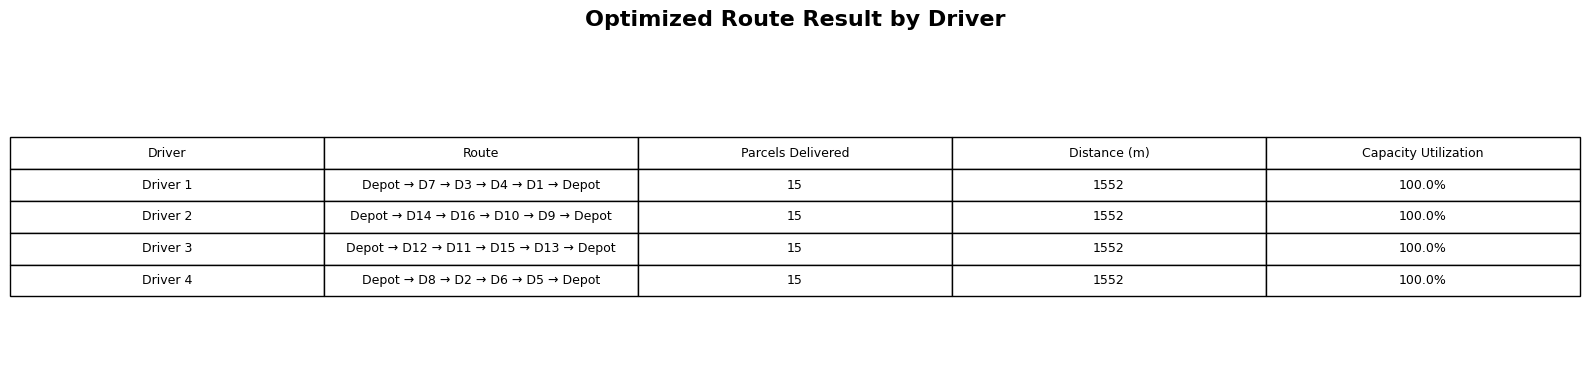

Saved route result table image to assets/route_result_table.png


In [11]:
def save_route_table_image(route_df, output_path="assets/route_result_table.png"):
    os.makedirs("assets", exist_ok=True)

    display_df = route_df[[
        "Driver",
        "Route",
        "Parcels Delivered",
        "Distance (m)",
        "Capacity Utilization"
    ]].copy()

    display_df["Capacity Utilization"] = (
        display_df["Capacity Utilization"] * 100
    ).round(1).astype(str) + "%"

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.axis("off")

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)

    plt.title(
        "Optimized Route Result by Driver",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved route result table image to {output_path}")

save_route_table_image(route_df)

In [12]:
def create_node_positions(num_nodes):
    positions = {}

    # Depot ở giữa
    positions[0] = (0, 0)

    # Các điểm giao hàng xếp vòng tròn xung quanh depot
    radius = 10
    angle_step = 2 * np.pi / (num_nodes - 1)

    for i in range(1, num_nodes):
        angle = (i - 1) * angle_step
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        positions[i] = (x, y)

    return positions

positions = create_node_positions(len(data["distance_matrix"]))
positions

{0: (0, 0),
 1: (np.float64(10.0), np.float64(0.0)),
 2: (np.float64(9.238795325112868), np.float64(3.826834323650898)),
 3: (np.float64(7.0710678118654755), np.float64(7.0710678118654755)),
 4: (np.float64(3.8268343236508984), np.float64(9.238795325112868)),
 5: (np.float64(6.123233995736766e-16), np.float64(10.0)),
 6: (np.float64(-3.826834323650897), np.float64(9.238795325112868)),
 7: (np.float64(-7.071067811865475), np.float64(7.0710678118654755)),
 8: (np.float64(-9.238795325112868), np.float64(3.826834323650899)),
 9: (np.float64(-10.0), np.float64(1.2246467991473533e-15)),
 10: (np.float64(-9.238795325112868), np.float64(-3.8268343236508966)),
 11: (np.float64(-7.071067811865477), np.float64(-7.071067811865475)),
 12: (np.float64(-3.8268343236509033), np.float64(-9.238795325112864)),
 13: (np.float64(-1.8369701987210296e-15), np.float64(-10.0)),
 14: (np.float64(3.8268343236509), np.float64(-9.238795325112866)),
 15: (np.float64(7.071067811865474), np.float64(-7.071067811865477

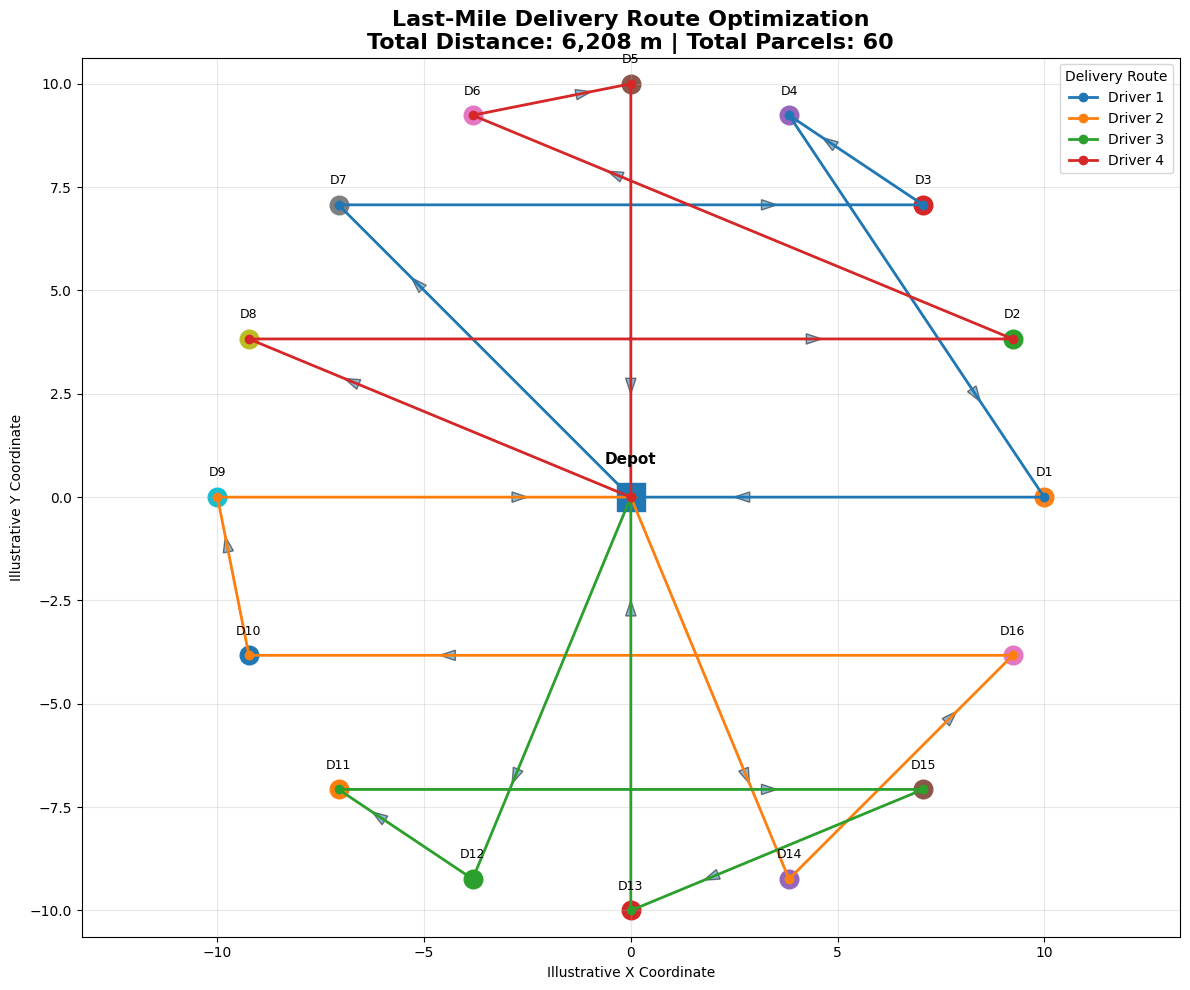

Saved route visualization to assets/route_optimization_result.png


In [13]:
def plot_routes(route_df, positions, output_path="assets/route_optimization_result.png"):
    os.makedirs("assets", exist_ok=True)

    plt.figure(figsize=(12, 10))

    # Vẽ nodes
    for node, (x, y) in positions.items():
        if node == 0:
            plt.scatter(x, y, s=400, marker="s")
            plt.text(x, y + 0.8, "Depot", ha="center", fontsize=11, fontweight="bold")
        else:
            plt.scatter(x, y, s=180)
            plt.text(x, y + 0.5, f"D{node}", ha="center", fontsize=9)

    # Vẽ từng route
    for _, row in route_df.iterrows():
        route_nodes = row["Route Nodes"]
        driver = row["Driver"]

        xs = [positions[node][0] for node in route_nodes]
        ys = [positions[node][1] for node in route_nodes]

        plt.plot(xs, ys, linewidth=2, marker="o", label=driver)

        # Thêm hướng mũi tên
        for i in range(len(route_nodes) - 1):
            start_node = route_nodes[i]
            end_node = route_nodes[i + 1]

            x_start, y_start = positions[start_node]
            x_end, y_end = positions[end_node]

            dx = x_end - x_start
            dy = y_end - y_start

            plt.arrow(
                x_start,
                y_start,
                dx * 0.75,
                dy * 0.75,
                length_includes_head=True,
                head_width=0.25,
                alpha=0.5
            )

    total_distance = route_df["Distance (m)"].sum()
    total_parcels = route_df["Parcels Delivered"].sum()

    plt.title(
        f"Last-Mile Delivery Route Optimization\n"
        f"Total Distance: {total_distance:,.0f} m | Total Parcels: {total_parcels}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Illustrative X Coordinate")
    plt.ylabel("Illustrative Y Coordinate")
    plt.legend(title="Delivery Route")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved route visualization to {output_path}")

plot_routes(route_df, positions)

In [14]:
def generate_business_insights(route_df, output_path="reports/business_insights.md"):
    os.makedirs("reports", exist_ok=True)

    total_parcels = route_df["Parcels Delivered"].sum()
    total_distance = route_df["Distance (m)"].sum()
    avg_distance = route_df["Distance (m)"].mean()
    longest_route = route_df["Distance (m)"].max()
    shortest_route = route_df["Distance (m)"].min()
    avg_capacity_utilization = route_df["Capacity Utilization"].mean()

    best_driver = route_df.loc[route_df["Distance (m)"].idxmin(), "Driver"]
    longest_driver = route_df.loc[route_df["Distance (m)"].idxmax(), "Driver"]

    insights = f"""
# Business Insights: Last-Mile Delivery Route Optimization

## Key Metrics

| Metric | Result |
|---|---:|
| Delivery drivers | {len(route_df)} |
| Total parcels assigned | {total_parcels} |
| Total optimized distance | {total_distance:,.0f} m |
| Average route distance | {avg_distance:,.0f} m |
| Shortest route | {shortest_route:,.0f} m |
| Longest route | {longest_route:,.0f} m |
| Average capacity utilization | {avg_capacity_utilization:.1%} |

## Key Insights

### 1. All delivery demand was successfully assigned

The optimization model assigned all {total_parcels} parcels to available delivery drivers while respecting vehicle capacity constraints.

### 2. Driver workload was balanced by parcel capacity

Each route was designed under the vehicle capacity limit. This helps prevent driver overload and supports fair workload allocation.

### 3. Route distance varies across drivers

The shortest route was assigned to {best_driver}, while the longest route was assigned to {longest_driver}. This suggests that future improvements can include workload balancing by both parcel volume and travel distance.

### 4. Route optimization supports last-mile logistics efficiency

The model can help e-commerce logistics teams reduce unnecessary travel distance, improve driver productivity, and support better delivery planning.

## Future Improvements

This project can be extended by adding:

- Real customer geolocation data
- Delivery time windows
- Driver working hour limits
- Fuel cost and vehicle operating cost
- Traffic conditions
- Priority orders
- Multiple depots
"""

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(insights)

    print(f"Saved business insights to {output_path}")
    print(insights)

generate_business_insights(route_df)

Saved business insights to reports/business_insights.md

# Business Insights: Last-Mile Delivery Route Optimization

## Key Metrics

| Metric | Result |
|---|---:|
| Delivery drivers | 4 |
| Total parcels assigned | 60 |
| Total optimized distance | 6,208 m |
| Average route distance | 1,552 m |
| Shortest route | 1,552 m |
| Longest route | 1,552 m |
| Average capacity utilization | 100.0% |

## Key Insights

### 1. All delivery demand was successfully assigned

The optimization model assigned all 60 parcels to available delivery drivers while respecting vehicle capacity constraints.

### 2. Driver workload was balanced by parcel capacity

Each route was designed under the vehicle capacity limit. This helps prevent driver overload and supports fair workload allocation.

### 3. Route distance varies across drivers

The shortest route was assigned to Driver 1, while the longest route was assigned to Driver 1. This suggests that future improvements can include workload balancing by both 